In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score,classification_report, confusion_matrix, accuracy_score

In [12]:
df = pd.read_csv("mushrooms.csv")
#target encoding
df["class"] = df["class"].map({"e": 0, "p": 1})

#one hot encoding for categorical features
X = pd.get_dummies(df.drop(columns=["class"]))
y = df["class"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling features (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test)    

In [14]:
learning_rates = np.arange(0.001, 1.001, 0.001)
train_f1 = []
test_f1 = []

for lr in learning_rates:

    model = SGDClassifier(
        loss="log_loss",
        learning_rate="constant",
        eta0=lr,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_f1.append(f1_score(y_train, y_train_pred, average="weighted"))
    test_f1.append(f1_score(y_test, y_test_pred, average="weighted"))


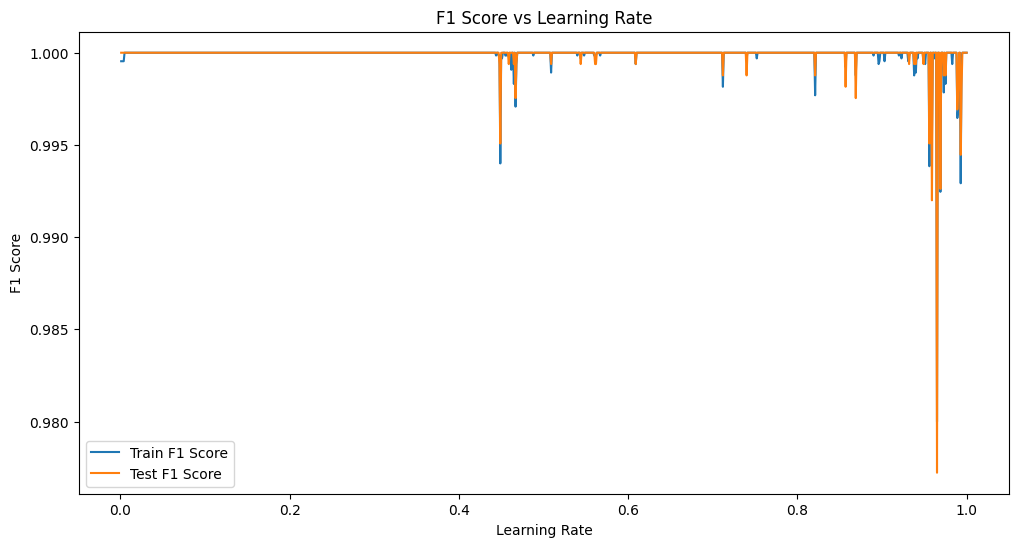

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(learning_rates, train_f1, label='Train F1 Score')
plt.plot(learning_rates, test_f1, label='Test F1 Score')
plt.xlabel('Learning Rate')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Learning Rate')
plt.legend()
plt.show()

In [16]:
best_index = test_f1.index(max(test_f1))

best_lr = learning_rates[best_index]
best_score = test_f1[best_index]

print("Best Learning Rate:", best_lr)
print("Best Test F1:", best_score)

Best Learning Rate: 0.001
Best Test F1: 1.0
